# Adaptive subspaces

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
import cupy as cp

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, make_scorer

from tqdm import tqdm

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors

import pickle
import warnings



In [3]:
handler = decode.DecodingDataHandler(
    data_dir='/data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


In [48]:
df_trials = pyal.select_trials(df_, df_.trial_name == 'trial')
df_trials = dt.add_pca_df(df_trials, n_components=30)
df_trials = dt.add_bhv(df_trials)
df_trials = dt.remove_trials_wo_motion_before_event(df_trials, 'idx_motion', 'idx_sol_on')
df_trials = pyal.restrict_to_interval(df_trials, 'idx_sol_on', rel_start = -200, rel_end= 300)

Dropped 11 of 333 rows (3.30%).


## Variance explained during perturbations

In [34]:
W_cp_comm = subspaces.compute_embedding(
    df_trials,
    'MOp_rates_pca',
    'CP_rates_pca',
    (50, 150),
    subspaces.ReducedRankCommSubspace(rank=10)
)

In [23]:
subspaces.variance_in_subspace(
    np.concatenate(df_trials.MOp_rates.values),
    W_cp_comm
)

533.2916824997735

In [21]:
subspaces.variance_in_dims(
    np.concatenate(df_trials.MOp_rates_pca.values),
    W_cp_comm
)

array([212.3929769 , 251.1542442 , 258.18389897, 256.77779316,
       248.36097867, 226.27170839, 232.55418866, 278.56712958,
       231.71292702, 784.91982818])

In [24]:
np.trace(
    np.cov(np.concatenate(df_trials.MOp_rates.values).T)
)

10123.071593359437

In [35]:
# Shape time, comp, trials, then sum along trials (time x comps), then sum comps
var_across_trials = subspaces.variance_in_subspace_df(df_trials, 'MOp_rates_pca', W_cp_comm)

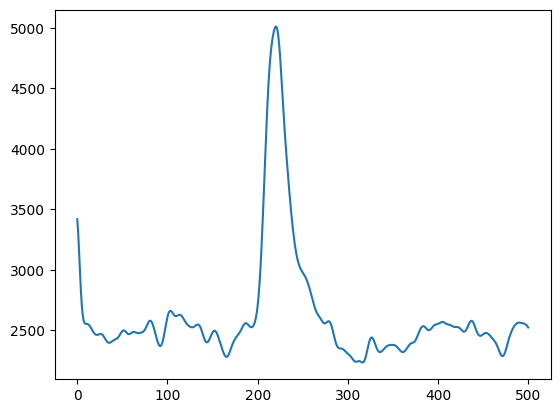

In [36]:
plt.plot(var_across_trials)

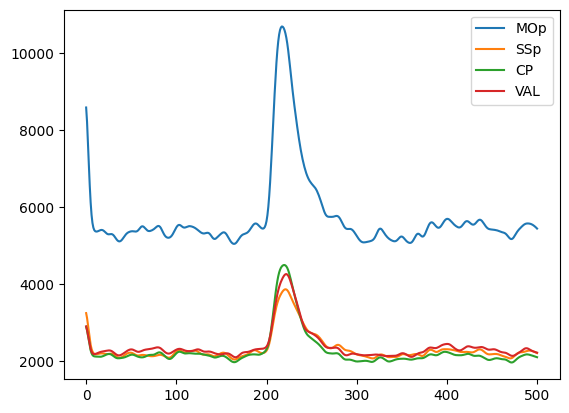

In [60]:
area_from = 'MOp'
areas = ['MOp', 'SSp', 'CP', 'VAL']
fig, ax = plt.subplots()
for area in areas:
    if area != area_from:
        W = subspaces.compute_embedding(
            df_trials,
            f'{area_from}_rates_pca',
            f'{area}_rates_pca',
            (50, 150),
            subspaces.ReducedRankCommSubspace(rank=10)
        )
        var_across_trials = subspaces.variance_in_subspace_df(df_trials, f'{area_from}_rates_pca', W)
    else:
        var_across_trials = subspaces.variance_in_subspace_df(df_trials, f'{area_from}_rates_pca', 
                                                              np.eye(df_trials[f'{area_from}_rates_pca'].values[0].shape[1]))
    ax.plot(var_across_trials, label=area)
ax.legend()

## How does rank change? 

In [73]:
area_from = 'MOp'
areas = 'CP'
scores = []
ranks = np.arange(2, 20, step=2)
for rank in tqdm(ranks):
    score = cross_val_score(
        decode.ReducedRankRegressorBence(rank=rank),
        np.concatenate(df_trials[f'{area_from}_rates']),
        np.concatenate(df_trials[f'{area}_rates']),
        scoring=decode.get_custom_scorer(),
        cv=4
    )
    scores.append(score)
scores = np.array(scores)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:24<?, ?it/s]


KeyboardInterrupt: 

In [70]:
scores.shape

(9, 4)

<ErrorbarContainer object of 3 artists>

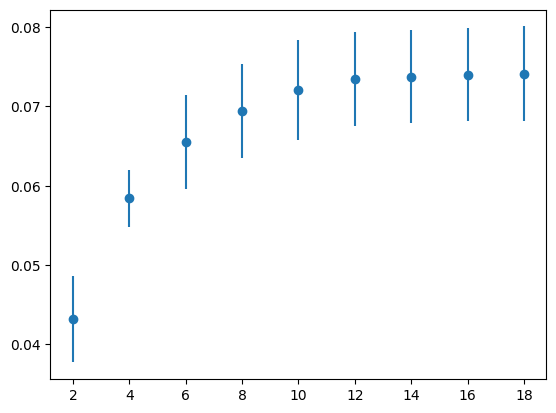

In [72]:
fig, ax = plt.subplots()
ax.errorbar(ranks, scores.mean(-1), scores.std(-1), fmt='o')